In [1]:
import pandas as pd

In [2]:
try:
    dataset = pd.read_excel("student_final_cgpa_dataset.xlsx")
except FileNotFoundError:
    print("File not Found")

In [7]:
dataset = dataset.drop(["Student_ID"] , axis=1)

In [8]:
X = dataset.drop(["Final_CGPA","Risk_Level"],axis=1)
y = dataset["Risk_Level"]

In [9]:
X

,Age,Mid_Term,Attendance,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Per_Week,Quiz,Assignment,Gender_Male,Major_Computer Science,Major_Economics,Major_Engineering,Major_Mathematics,Major_Psychology
0,20,73.5,83.9,4.4,2.65,9.1,8,7.4,7.2,True,False,False,True,False,False
1,24,92.9,80.7,4.0,3.58,4.0,4,9.3,9.7,False,False,False,False,False,False
2,20,98.9,91.5,3.9,3.29,6.7,4,10.0,9.0,False,False,False,False,True,False
3,23,100.0,73.9,8.8,3.48,4.0,6,10.0,9.6,False,False,False,True,False,False
4,21,56.6,79.8,2.2,2.66,8.7,6,5.6,6.7,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,23,82.4,83.9,2.4,3.21,7.5,8,8.2,9.4,False,False,False,False,True,False
4996,20,98.2,82.8,7.2,3.12,7.6,7,10.0,8.8,True,False,True,False,False,False
4997,19,100.0,92.2,13.5,3.55,6.3,6,10.0,10.0,True,False,False,True,False,False
4998,22,79.7,100.0,2.4,2.86,7.0,6,8.1,8.1,False,True,False,False,False,False


In [10]:
y

0                 Safe
1       High Performer
2       High Performer
3       High Performer
4              At Risk
             ...      
4995              Safe
4996    High Performer
4997    High Performer
4998              Safe
4999              Safe
Name: Risk_Level, Length: 5000, dtype: object

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [12]:
y = le.fit_transform(y)

In [13]:
y[:10]

array([2, 1, 1, 1, 0, 0, 2, 1, 1, 2])

In [14]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test , y_train , y_test = train_test_split(
        X,y,
        test_size=0.2,
        random_state=42
)

In [17]:
X_train =  sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [18]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [19]:
model.fit(X_train,y_train)

RandomForestClassifier()

In [20]:
R_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

In [23]:
print("Accurecy: ", accuracy_score(y_test,R_pred))

Accurecy:  0.901


In [24]:
print(classification_report(y_test,R_pred))

              precision    recall  f1-score   support

           0       0.93      0.73      0.81        91
           1       0.95      0.87      0.91       398
           2       0.87      0.95      0.91       511

    accuracy                           0.90      1000
   macro avg       0.91      0.85      0.88      1000
weighted avg       0.90      0.90      0.90      1000



In [26]:
confusion_matrix(y_test,R_pred)

array([[ 66,   0,  25],
       [  0, 348,  50],
       [  5,  19, 487]])

In [27]:
import matplotlib.pyplot as plt 
import seaborn as sns

<Axes: >

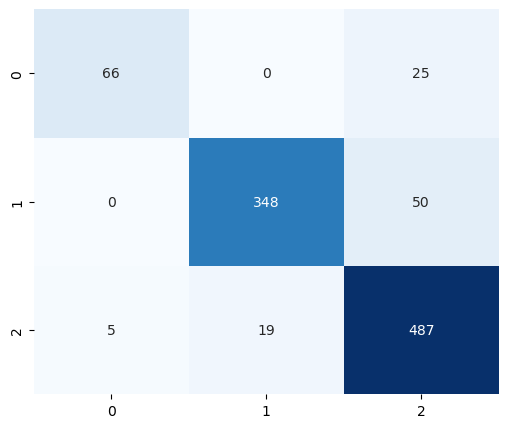

In [28]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test,R_pred), annot=True , fmt='d',cmap='Blues',cbar=False)